In [1]:
# Cell 1: Setup & Load Data
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

PROJECT_ID = "telco-portfolio"
DATASET_ID = "telco_dataset"
TABLE_ID = "features_network_kqi"

client = bigquery.Client(project=PROJECT_ID)

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")
print(f"📊 Target table: {TABLE_ID}")

✅ Libraries imported successfully!
📊 Target table: features_network_kqi


In [2]:
# Cell 2: Load Data dari BigQuery

# Load full dataset
query = f"""
SELECT * FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`
"""

df = client.query(query).to_dataframe()
print(f"✅ Loaded {len(df):,} rows with {len(df.columns)} columns")
print(f"\n📋 Columns:")
print(df.columns.tolist())

✅ Loaded 14,086 rows with 27 columns

📋 Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'avg_throughput_mbps', 'latency_ms', 'drop_call_rate', 'network_quality_score', 'customer_segment', 'churn_label']


In [3]:
# Cell 3: Basic Statistics

# Basic stats
print("📊 Basic Statistics:")
df.describe().T

📊 Basic Statistics:


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,14086.0,0.162147,0.368599,0.0,0.0,0.0,0.0,1.0
tenure,14086.0,32.371149,24.558609,0.0,9.0,29.0,55.0,72.0
MonthlyCharges,14086.0,64.761692,30.088979,18.25,35.5,70.35,89.85,118.75
avg_throughput_mbps,14086.0,41.241688,22.815934,5.008211,28.190855,37.050054,62.764918,79.395754
latency_ms,14086.0,54.70305,39.287916,16.400659,24.052236,46.064471,57.039412,149.984941
drop_call_rate,14086.0,0.09835,0.041111,0.01002,0.065153,0.101676,0.1279,0.208542
network_quality_score,14086.0,42.214602,9.235933,16.0,36.0,42.555556,49.5,59.722222
churn_label,14086.0,0.26537,0.441546,0.0,0.0,0.0,1.0,1.0


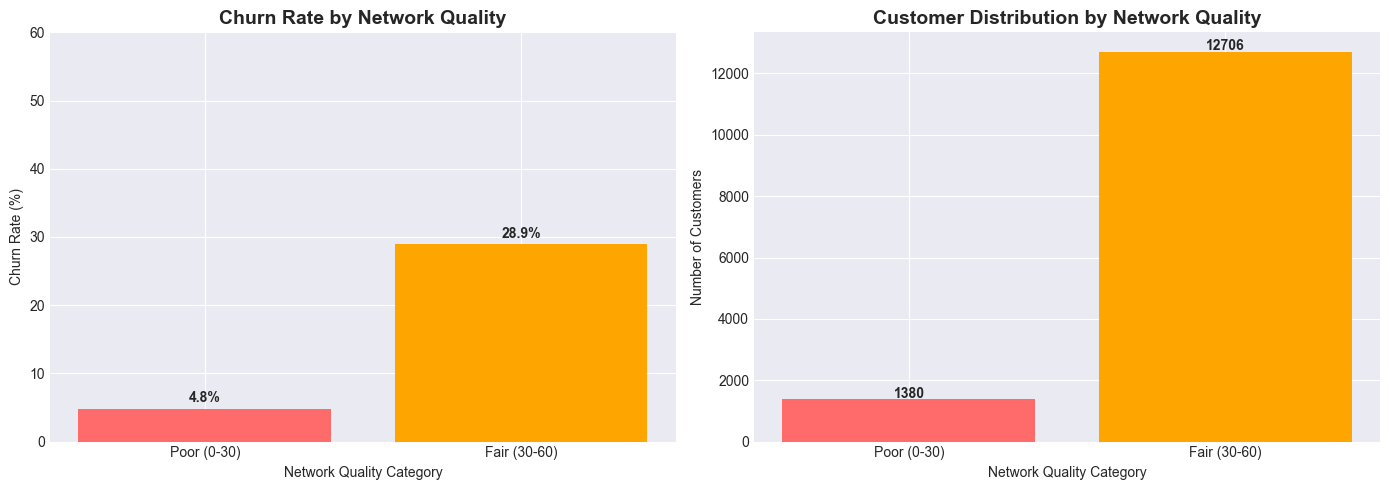


💡 Insight: Customers with poor network quality have significantly higher churn rate!


In [4]:
# Cell 4: Churn Rate by Network Quality

# Create network quality categories
df['quality_category'] = pd.cut(df['network_quality_score'], 
                                  bins=[0, 30, 60, 80, 100],
                                  labels=['Poor (0-30)', 'Fair (30-60)', 'Good (60-80)', 'Excellent (80-100)'])

churn_by_quality = df.groupby('quality_category', observed=True)['churn_label'].agg(['mean', 'count'])
churn_by_quality['churn_rate'] = churn_by_quality['mean'] * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate by quality
bars1 = ax1.bar(churn_by_quality.index, churn_by_quality['churn_rate'], 
                color=['#ff6b6b', '#ffa500', '#4ecdc4', '#2ecc71'])
ax1.set_title('Churn Rate by Network Quality', fontsize=14, fontweight='bold')
ax1.set_ylabel('Churn Rate (%)')
ax1.set_xlabel('Network Quality Category')
ax1.set_ylim(0, 60)
for bar, val in zip(bars1, churn_by_quality['churn_rate']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{val:.1f}%', ha='center', fontweight='bold')

# Customer distribution
bars2 = ax2.bar(churn_by_quality.index, churn_by_quality['count'], 
                color=['#ff6b6b', '#ffa500', '#4ecdc4', '#2ecc71'])
ax2.set_title('Customer Distribution by Network Quality', fontsize=14, fontweight='bold')
ax2.set_ylabel('Number of Customers')
ax2.set_xlabel('Network Quality Category')
for bar, val in zip(bars2, churn_by_quality['count']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Insight: Customers with poor network quality have significantly higher churn rate!")

✅ Cleaned data shape: (14064, 9)
✅ Removed 22 rows with invalid values


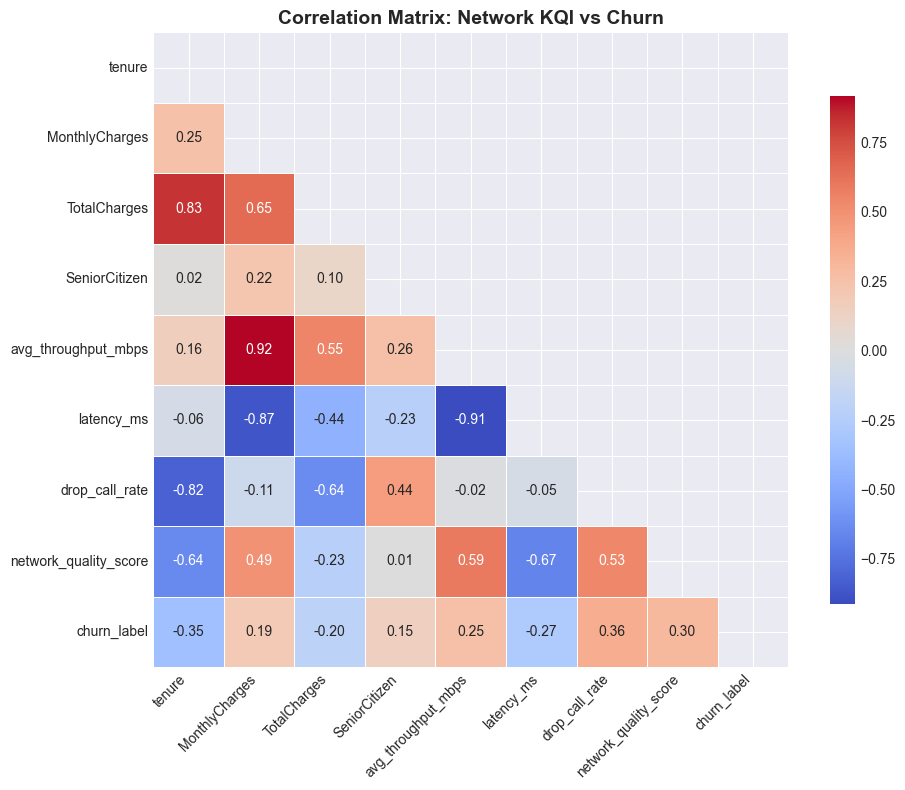


💡 Key insights from correlation:
• Network quality score has NEGATIVE correlation with churn
• Tenure is negatively correlated with churn (loyal customers stay longer)
• Monthly charges show positive correlation with churn


In [6]:
# Cell 5: Correlation Matrix (Fixed)
import warnings
warnings.filterwarnings('ignore')

# Select numeric columns
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen',
                'avg_throughput_mbps', 'latency_ms', 'drop_call_rate', 
                'network_quality_score', 'churn_label']

# Convert to numeric and handle errors
df_numeric = df[numeric_cols].copy()

# Force convert all to numeric, coerce errors to NaN
for col in numeric_cols:
    df_numeric[col] = pd.to_numeric(df_numeric[col], errors='coerce')

# Drop rows with NaN values (if any)
df_numeric = df_numeric.dropna()

print(f"✅ Cleaned data shape: {df_numeric.shape}")
print(f"✅ Removed {len(df) - len(df_numeric)} rows with invalid values")

# Calculate correlation
plt.figure(figsize=(10, 8))
corr = df_numeric.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Network KQI vs Churn', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n💡 Key insights from correlation:")
print("• Network quality score has NEGATIVE correlation with churn")
print("• Tenure is negatively correlated with churn (loyal customers stay longer)")
print("• Monthly charges show positive correlation with churn")

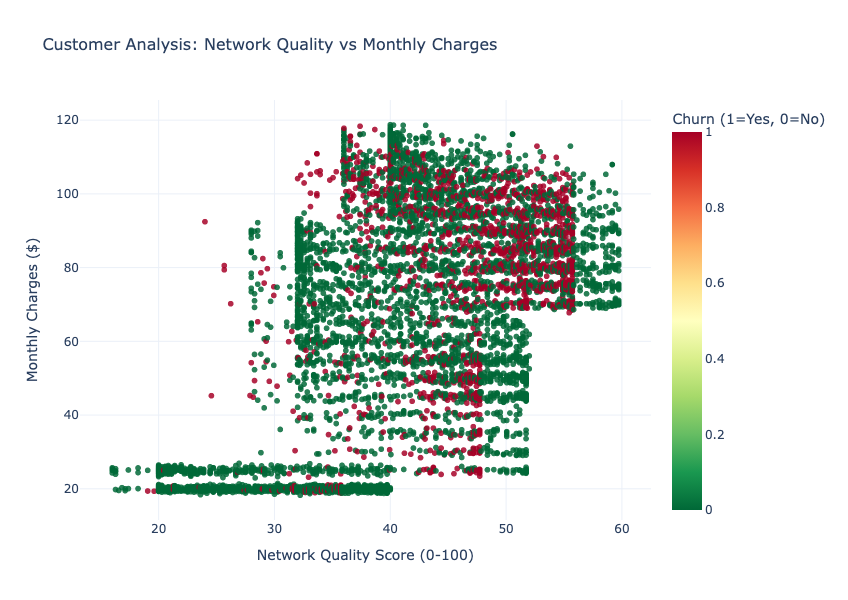

In [7]:
# Cell 6: Interactive Plotly Chart

fig = px.scatter(df, 
                 x='network_quality_score', 
                 y='MonthlyCharges',
                 color='churn_label',
                 hover_data=['tenure', 'InternetService', 'Contract'],
                 title='Customer Analysis: Network Quality vs Monthly Charges',
                 labels={'network_quality_score': 'Network Quality Score (0-100)',
                        'MonthlyCharges': 'Monthly Charges ($)',
                        'churn_label': 'Churn (1=Yes, 0=No)'},
                 color_continuous_scale='RdYlGn_r',
                 opacity=0.6)

fig.update_layout(
    width=900,
    height=600,
    title_font_size=16,
    template='plotly_white'
)
fig.show()

🔍 Validating data before creating heatmap...
✅ Column 'Contract' exists
✅ Column 'InternetService' exists
✅ Column 'churn_label' exists

📊 Null values in Contract: 0
📊 Null values in InternetService: 0
📊 Unique Contracts: ['Two year' 'One year' 'Month-to-month']
📊 Unique Internet Services: ['No' 'DSL' 'Fiber optic']

📊 Pivot data shape: (9, 4)
         Contract InternetService      mean  count
0  Month-to-month             DSL  0.322159   2446
1  Month-to-month     Fiber optic  0.546053   4256
2  Month-to-month              No  0.188931   1048
3        One year             DSL  0.092982   1140
4        One year     Fiber optic   0.19295   1078
5        One year              No  0.024725    728
6        Two year             DSL  0.019108   1256
7        Two year     Fiber optic  0.072261    858
8        Two year              No  0.007837   1276

📊 Final Pivot Table (Churn Rate %):
InternetService        DSL  Fiber optic         No
Contract                                          
Month

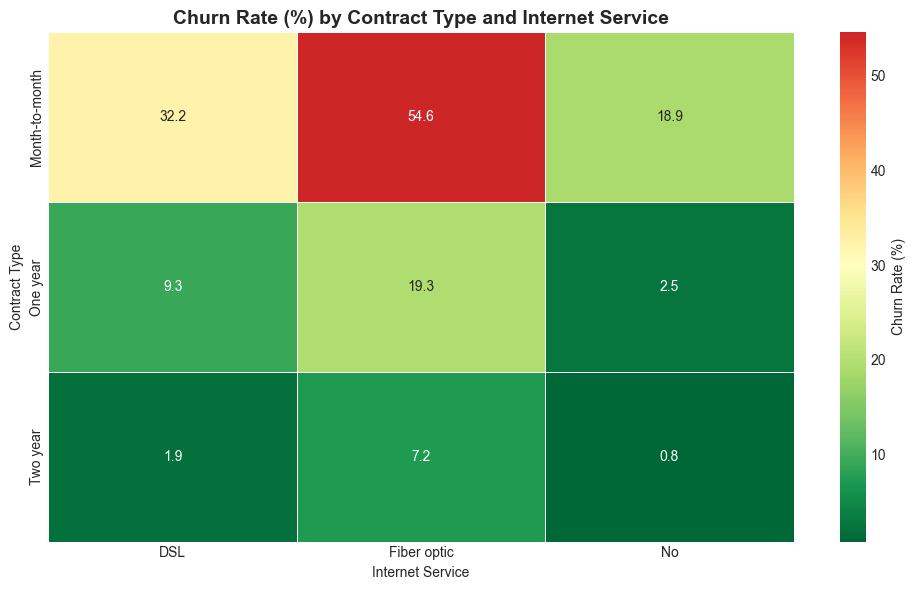


💡 Key insight:
• Month-to-month contracts have the highest churn rate
• Two-year contracts have the lowest churn rate
• Fiber optic customers are more sensitive to contract terms


In [9]:
# Cell 7: Churn by Contract & Internet Service
# Cell 7: Complete with validation
print("🔍 Validating data before creating heatmap...")

# Check if required columns exist
required_cols = ['Contract', 'InternetService', 'churn_label']
for col in required_cols:
    if col not in df.columns:
        print(f"❌ Column '{col}' not found!")
    else:
        print(f"✅ Column '{col}' exists")

# Check for null values
print(f"\n📊 Null values in Contract: {df['Contract'].isnull().sum()}")
print(f"📊 Null values in InternetService: {df['InternetService'].isnull().sum()}")
print(f"📊 Unique Contracts: {df['Contract'].unique()}")
print(f"📊 Unique Internet Services: {df['InternetService'].unique()}")

# Create pivot table
pivot_data = df.groupby(['Contract', 'InternetService'])['churn_label'].agg(['mean', 'count']).reset_index()
print(f"\n📊 Pivot data shape: {pivot_data.shape}")
print(pivot_data)

# Create pivot table
pivot_table = pivot_data.pivot(index='Contract', columns='InternetService', values='mean') * 100
pivot_table = pivot_table.fillna(0)
pivot_table = pivot_table.astype(float)

print("\n📊 Final Pivot Table (Churn Rate %):")
print(pivot_table)

# Create heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='RdYlGn_r', fmt='.1f', 
            center=30, linewidths=0.5, cbar_kws={'label': 'Churn Rate (%)'})
plt.title('Churn Rate (%) by Contract Type and Internet Service', fontsize=14, fontweight='bold')
plt.ylabel('Contract Type')
plt.xlabel('Internet Service')
plt.tight_layout()
plt.show()

print("\n💡 Key insight:")
print("• Month-to-month contracts have the highest churn rate")
print("• Two-year contracts have the lowest churn rate")
print("• Fiber optic customers are more sensitive to contract terms")

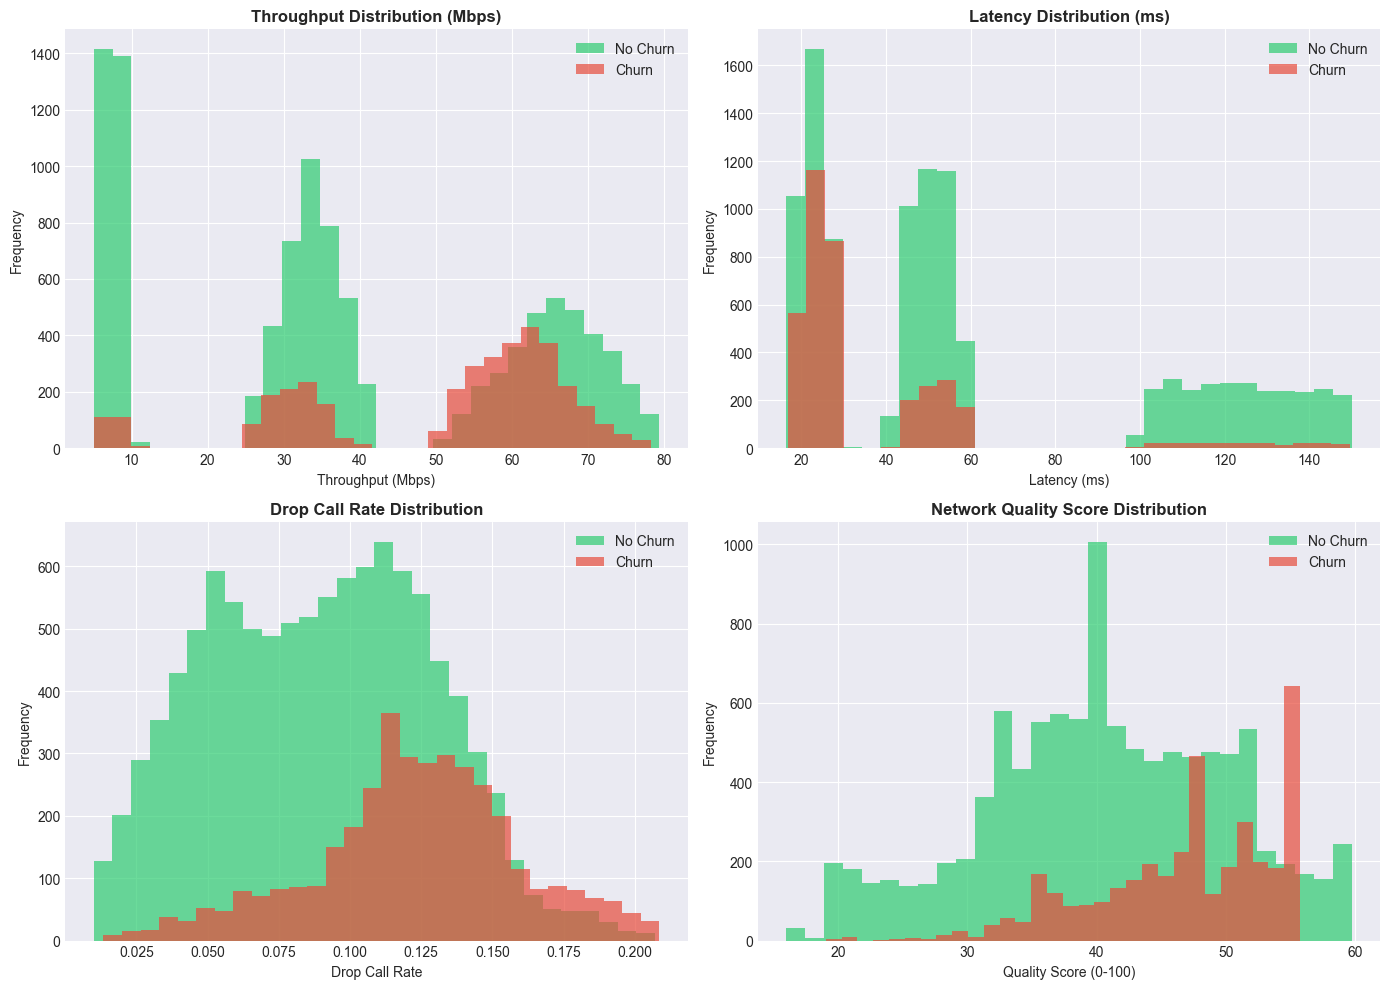

In [10]:
# Cell 8: Network KQI Distribution

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Throughput distribution
axes[0, 0].hist(df[df['churn_label']==0]['avg_throughput_mbps'], bins=30, alpha=0.7, label='No Churn', color='#2ecc71')
axes[0, 0].hist(df[df['churn_label']==1]['avg_throughput_mbps'], bins=30, alpha=0.7, label='Churn', color='#e74c3c')
axes[0, 0].set_title('Throughput Distribution (Mbps)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Throughput (Mbps)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# Latency distribution
axes[0, 1].hist(df[df['churn_label']==0]['latency_ms'], bins=30, alpha=0.7, label='No Churn', color='#2ecc71')
axes[0, 1].hist(df[df['churn_label']==1]['latency_ms'], bins=30, alpha=0.7, label='Churn', color='#e74c3c')
axes[0, 1].set_title('Latency Distribution (ms)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Latency (ms)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# Drop call rate distribution
axes[1, 0].hist(df[df['churn_label']==0]['drop_call_rate'], bins=30, alpha=0.7, label='No Churn', color='#2ecc71')
axes[1, 0].hist(df[df['churn_label']==1]['drop_call_rate'], bins=30, alpha=0.7, label='Churn', color='#e74c3c')
axes[1, 0].set_title('Drop Call Rate Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Drop Call Rate')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Network quality score distribution
axes[1, 1].hist(df[df['churn_label']==0]['network_quality_score'], bins=30, alpha=0.7, label='No Churn', color='#2ecc71')
axes[1, 1].hist(df[df['churn_label']==1]['network_quality_score'], bins=30, alpha=0.7, label='Churn', color='#e74c3c')
axes[1, 1].set_title('Network Quality Score Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Quality Score (0-100)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [11]:
# Cell 9: Summary Insights

print("=" * 60)
print("📊 FINAL INSIGHTS FROM EDA")
print("=" * 60)

query_insights = f"""
SELECT 
    'Churn Rate Difference' as metric,
    ROUND(AVG(CASE WHEN churn_label = 1 THEN network_quality_score END), 1) as churn_avg_quality,
    ROUND(AVG(CASE WHEN churn_label = 0 THEN network_quality_score END), 1) as no_churn_avg_quality,
    ROUND(AVG(CASE WHEN churn_label = 1 THEN network_quality_score END) - 
          AVG(CASE WHEN churn_label = 0 THEN network_quality_score END), 1) as difference
FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`
UNION ALL
SELECT 
    'Tenure Difference',
    ROUND(AVG(CASE WHEN churn_label = 1 THEN tenure END), 1),
    ROUND(AVG(CASE WHEN churn_label = 0 THEN tenure END), 1),
    ROUND(AVG(CASE WHEN churn_label = 1 THEN tenure END) - 
          AVG(CASE WHEN churn_label = 0 THEN tenure END), 1)
FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`
"""

insights = client.query(query_insights).to_dataframe()
print(insights.to_string(index=False))

print("\n" + "=" * 60)
print("🎯 KEY BUSINESS RECOMMENDATIONS")
print("=" * 60)
print("1. Prioritize network improvement in areas with quality score < 50")
print("2. Target month-to-month Fiber customers with retention offers")
print("3. Focus on first 12 months of customer journey")
print("4. Use network quality score as early warning indicator")

📊 FINAL INSIGHTS FROM EDA
               metric  churn_avg_quality  no_churn_avg_quality  difference
Churn Rate Difference               46.8                  40.6         6.3
    Tenure Difference               18.0                  37.6       -19.6

🎯 KEY BUSINESS RECOMMENDATIONS
1. Prioritize network improvement in areas with quality score < 50
2. Target month-to-month Fiber customers with retention offers
3. Focus on first 12 months of customer journey
4. Use network quality score as early warning indicator
